# Grokking

The term **grok** was coined by Robert A. Heinlein in his 1961 science fiction novel *Stranger in a Strange Land*. In the novel, "to grok" means to understand something so thoroughly that it becomes a part of you, a deep, almost instinctive integration of knowledge. The term migrated into hacker culture in the 1970s and 1980s, where it meant fully internalizing a concept to the point of intuitive mastery.

In human learning, grokking implies:

* Going beyond rote memorization
* Achieving a mental model that allows flexible application
* Being able to generalize knowledge to novel contexts without hesitation

This literary and cultural meaning reappears today in an entirely different context: **deep learning training dynamics**.

---

## Grokking in Machine Learning

In 2021, researchers at OpenAI and elsewhere began to document an unexpected phenomenon during neural network training on small, synthetic datasets: **test accuracy remained low long after training accuracy reached 100%, then suddenly and rapidly improved after a very long training period**. They borrowed Heinlein’s term "grokking" to describe it.

### The Setup

* **Datasets**: Often algorithmic tasks like modular addition or parity.
* **Model**: Transformer or simple feedforward network.
* **Observation**: The model can memorize the training set perfectly but fails to generalize for tens or hundreds of times longer than the time it took to memorize. Then, almost abruptly, generalization appears.

### The Key Pattern

1. **Memorization Phase**: Rapid drop in training error; test error remains high.
2. **Stasis Phase**: Training error stays near zero, test error plateaus at a poor level.
3. **Grokking Phase**: Test error suddenly collapses to near zero.

---

## Why Grokking Happens

While the exact mechanisms are still debated, the leading theories involve the interplay between **memorization** and **generalization** in overparameterized models.

### Competing Solutions

The model can represent multiple functions that fit the training data:

* **Memorization-based solution**: Fits only the training points; poor generalization.
* **Generalization-based solution**: Captures the underlying algorithm or structure.

During training:

* Stochastic gradient descent (SGD) finds the memorization solution first because it is easier to fit exactly.
* Over time, continued training with regularization nudges the model toward the more general solution, which eventually dominates.

### Regularization and Implicit Bias

Several studies have shown:

* **Weight decay (L2 regularization)** accelerates grokking by penalizing memorization-heavy solutions.
* The implicit bias of SGD in large models may favor simpler functions over time, but this bias is weak without explicit regularization.

---

## Formalization Attempts

Researchers have tried to model grokking mathematically.

**Key insights**:

* It can be seen as a phase transition between two attractors in the parameter space.
* The "energy" of a generalizing solution can be slightly lower than that of a memorizing one, but it is harder to reach without a long optimization path.
* Some work connects it to the **double descent** phenomenon: grokking is like a temporal version of the same underlying dynamics.

::: callout-important
## Double Descent in a Nutshell
In classical statistics, the **bias–variance tradeoff** predicts a U-shaped test error curve: error falls as model complexity increases, then rises again due to overfitting.  

Modern ML models, especially deep neural networks, often break this pattern. The **double descent** curve has:
1. **First descent:** Increasing complexity reduces bias and test error.
2. **Peak at interpolation:** Test error spikes when the model just fits the training data (zero training error).
3. **Second descent:** Further increasing complexity lowers test error again, because overparameterized models can still generalize due to optimization biases and implicit regularization.

**Key takeaway:** In some regimes, making the model *bigger* after the overfitting point can actually improve generalization.
:::


---

## Implications for AI Research

Grokking challenges the assumption that early stopping always preserves generalization. In some cases, **very long training** is required for true generalization to emerge. This matters for:

* **Curriculum design**: Knowing when to persist training.
* **Regularization strategy**: Understanding how weight decay and data augmentation affect late-stage learning.
* **Interpretability**: Tracking how representations change during the memorization-to-generalization transition.


Table: Practical Lessons

| Training Aspect        | Effect on Grokking                                   |
| ---------------------- | ---------------------------------------------------- |
| Weight Decay           | Strongly accelerates generalization onset            |
| Data Augmentation      | Can shorten or eliminate stasis phase                |
| Batch Size             | Smaller batches may encourage better exploration     |
| Learning Rate Schedule | Gradual decay helps stabilize late-stage convergence |
| Model Size             | Larger models can exacerbate the memorization phase  |

---

## Open Questions

1. **Scaling**: Does grokking occur in large-scale natural language models, or is it an artifact of small synthetic data?
2. **Representation Dynamics**: What changes in hidden representations mark the shift?
3. **Algorithmic Detection**: Can we predict grokking onset without just "waiting and seeing"?
4. **Connection to Human Learning**: Are there parallels to the "aha" moments in human cognition?


---

## Roadmap of the experiments

We will reproduce grokking on modular addition classification. You will train a tiny transformer on pairs of integers, predict their sum modulo a prime $p$, and monitor train and test curves. You will sweep weight decay and show that stronger explicit regularization accelerates grokking.

**Modules:**

* Data: synthetic modular arithmetic dataset
* Model: small transformer classifier, plus a compact MLP baseline
* Training: SGD or AdamW, with weight decay
* Tracking: accuracy and loss, train versus test
* Figures: learning curves and phase plots

---

## Setup


In [8]:

# If you run in a clean environment, uncomment the next lines to install deps:
# %pip install torch matplotlib numpy

import math, os, random, time
import numpy as np
import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader, random_split
import matplotlib.pyplot as plt

device = "cuda" if torch.cuda.is_available() else "cpu"
torch.manual_seed(1337); np.random.seed(1337); random.seed(1337)


## Synthetic dataset: modular addition

Task: given two integers $a, b \in \{0, \ldots, p-1\}$, predict $(a + b) \bmod p$. Choose a prime $p$ to ensure a clean group structure.



In [9]:
class ModAddDataset(Dataset):
    def __init__(self, p=97, split="train", train_fraction=0.5):
        """
        Build all ordered pairs (a, b) in [0, p-1]^2 with label (a + b) mod p.
        Then split deterministically into train and test by hashing index.
        """
        self.p = p
        pairs = [(a, b) for a in range(p) for b in range(p)]
        X = np.array(pairs, dtype=np.int64)
        y = (X[:,0] + X[:,1]) % p
        # deterministic split: first K% for train, remainder for test
        n = len(X)
        n_train = int(train_fraction * n)
        # shuffle once with fixed seed
        rng = np.random.default_rng(42)
        idx = np.arange(n); rng.shuffle(idx)
        train_idx, test_idx = idx[:n_train], idx[n_train:]
        if split == "train":
            self.X, self.y = X[train_idx], y[train_idx]
        else:
            self.X, self.y = X[test_idx], y[test_idx]

    def __len__(self): return len(self.X)
    def __getitem__(self, i):
        a, b = self.X[i]
        return torch.tensor([a, b], dtype=torch.long), torch.tensor(self.y[i], dtype=torch.long)




Quick sanity check:



In [10]:

train_ds = ModAddDataset(p=97, split="train", train_fraction=0.5)
test_ds  = ModAddDataset(p=97, split="test",  train_fraction=0.5)
len(train_ds), len(test_ds), train_ds[0]


(4704, 4705, (tensor([ 4, 36]), tensor(40)))



---

## 5. Encodings and models

Two simple architectures:

1. **Transformer classifier** that takes two token IDs $a$, $b$ and predicts a class in $\{0, \ldots, p-1\}$. This mirrors classic grokking setups and tends to show the effect clearly.

2. **MLP baseline** that receives concatenated one-hots for $a$ and $b$. This can also grok, but the transformer usually makes the dynamics more visible with fewer tricks.

### 5.1 Transformer model



In [11]:

class TinyGrokTransformer(nn.Module):
    def __init__(self, p=97, d_model=64, nhead=4, nlayers=2, d_ff=128, dropout=0.0):
        super().__init__()
        self.p = p
        self.embed = nn.Embedding(p, d_model)
        self.pos = nn.Parameter(torch.randn(2, d_model) * 0.02)  # positions for two tokens
        enc_layer = nn.TransformerEncoderLayer(d_model=d_model, nhead=nhead, dim_feedforward=d_ff, dropout=dropout, batch_first=True)
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=nlayers)
        self.norm = nn.LayerNorm(d_model)
        self.head = nn.Linear(d_model, p)

    def forward(self, x):
        # x shape: (B, 2) with token ids a, b
        h = self.embed(x) + self.pos.unsqueeze(0)
        h = self.encoder(h)
        h = self.norm(h)
        # pool by taking first token representation
        h = h[:, 0, :]
        logits = self.head(h)
        return logits




### MLP baseline



In [12]:

class ModAddMLP(nn.Module):
    def __init__(self, p=97, hidden=256):
        super().__init__()
        self.p = p
        self.register_buffer("eye", torch.eye(p))
        inp = 2 * p
        self.net = nn.Sequential(
            nn.Linear(inp, hidden),
            nn.ReLU(),
            nn.Linear(hidden, hidden),
            nn.ReLU(),
            nn.Linear(hidden, p)
        )
    def forward(self, x):
        # one-hot encode a and b, then concat
        a, b = x[:,0], x[:,1]
        oh = torch.cat([self.eye[a], self.eye[b]], dim=1)  # (B, 2p)
        return self.net(oh)


## Training loop with logging

We will use AdamW so weight decay is explicit. We also vary weight decay to show its effect on the grokking time.



In [13]:

def accuracy(logits, y):
    return (logits.argmax(dim=-1) == y).float().mean().item()

def train_model(model, train_ds, test_ds, epochs=2000, batch_size=512, lr=1e-3, weight_decay=1e-3, report_every=50):
    model.to(device)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=4096, shuffle=False)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()

    history = {"epoch": [], "train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best_test = 0.0

    for ep in range(1, epochs + 1):
        model.train()
        tloss = tcorrect = tcount = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            tloss += loss.item() * xb.size(0)
            tcorrect += (logits.argmax(dim=-1) == yb).sum().item()
            tcount += xb.size(0)
        train_loss = tloss / tcount
        train_acc = tcorrect / tcount

        model.eval()
        with torch.no_grad():
            vloss = vcorrect = vcount = 0.0
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                vloss += loss.item() * xb.size(0)
                vcorrect += (logits.argmax(dim=-1) == yb).sum().item()
                vcount += xb.size(0)
            test_loss = vloss / vcount
            test_acc = vcorrect / vcount

        history["epoch"].append(ep)
        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if ep % report_every == 0:
            print(f"ep {ep:5d}  train_acc {train_acc:0.3f}  test_acc {test_acc:0.3f}  wd {weight_decay:g}")

    return history


## 7. Running the experiment

We will try two conditions: low weight decay and high weight decay. Expectation: higher weight decay reduces the duration of the stasis plateau and accelerates generalization.



In [14]:

p = 97
train_ds = ModAddDataset(p=p, split="train", train_fraction=0.5)
test_ds  = ModAddDataset(p=p, split="test",  train_fraction=0.5)

configs = [
    {"label": "Transformer, wd=1e-6", "model": TinyGrokTransformer(p=p, d_model=64, nhead=4, nlayers=2, d_ff=128, dropout=0.0), "wd": 1e-6},
    {"label": "Transformer, wd=1e-2", "model": TinyGrokTransformer(p=p, d_model=64, nhead=4, nlayers=2, d_ff=128, dropout=0.0), "wd": 1e-2},
]

histories = []
for cfg in configs:
    print("Training:", cfg["label"])
    h = train_model(cfg["model"], train_ds, test_ds, epochs=1500, batch_size=512, lr=3e-4, weight_decay=cfg["wd"], report_every=100)
    h["label"] = cfg["label"]
    histories.append(h)


Training: Transformer, wd=1e-6
ep   100  train_acc 0.435  test_acc 0.006  wd 1e-06
ep   200  train_acc 0.989  test_acc 0.018  wd 1e-06
ep   300  train_acc 1.000  test_acc 0.026  wd 1e-06
ep   400  train_acc 1.000  test_acc 0.028  wd 1e-06
ep   500  train_acc 1.000  test_acc 0.031  wd 1e-06
ep   600  train_acc 1.000  test_acc 0.032  wd 1e-06
ep   700  train_acc 1.000  test_acc 0.032  wd 1e-06
ep   800  train_acc 1.000  test_acc 0.033  wd 1e-06
ep   900  train_acc 1.000  test_acc 0.034  wd 1e-06
ep  1000  train_acc 1.000  test_acc 0.037  wd 1e-06
ep  1100  train_acc 1.000  test_acc 0.038  wd 1e-06
ep  1200  train_acc 1.000  test_acc 0.039  wd 1e-06
ep  1300  train_acc 1.000  test_acc 0.040  wd 1e-06
ep  1400  train_acc 1.000  test_acc 0.040  wd 1e-06
ep  1500  train_acc 1.000  test_acc 0.039  wd 1e-06
Training: Transformer, wd=1e-2
ep   100  train_acc 0.389  test_acc 0.005  wd 0.01
ep   200  train_acc 0.987  test_acc 0.022  wd 0.01
ep   300  train_acc 1.000  test_acc 0.031  wd 0.01
ep   



---

## 8. Plotting learning curves

You should see training accuracy rise to near one very early in both conditions. The test accuracy will lag. With stronger weight decay, the test curve will rise much earlier.



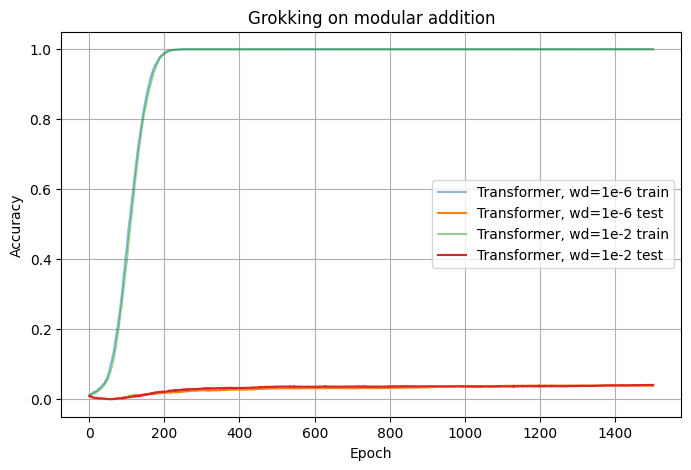

In [15]:

def plot_histories(histories):
    plt.figure(figsize=(8,5))
    for h in histories:
        ep = np.array(h["epoch"])
        ta = np.array(h["train_acc"])
        va = np.array(h["test_acc"])
        plt.plot(ep, ta, alpha=0.5, label=f'{h["label"]} train')
        plt.plot(ep, va, alpha=1.0, label=f'{h["label"]} test')
    plt.xlabel("Epoch"); plt.ylabel("Accuracy")
    plt.title("Grokking on modular addition")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_histories(histories)




**Figure 1.** Expected grokking pattern: training accuracy saturates quickly; test accuracy eventually rises, earlier with larger weight decay.

---

## 9. Verifying that the model learned the rule, not just the examples

We can challenge the model with inputs in a structured pattern, for example all $(a, b)$ where $a = b$, which are rare in random batches. True rule learning will yield perfect accuracy on this slice.



In [16]:

def slice_eval_equal_pairs(model, p=97):
    model.eval()
    with torch.no_grad():
        pairs = torch.arange(p, dtype=torch.long)
        a = pairs
        b = pairs
        X = torch.stack([a, b], dim=1).to(device)
        y = ((a + b) % p).to(device)
        logits = model(X)
        acc = (logits.argmax(dim=-1) == y).float().mean().item()
    return acc

# Example usage with the last trained model in each config
slice_scores = []
for cfg, h in zip(configs, histories):
    model = cfg["model"]
    score = slice_eval_equal_pairs(model, p=p)
    slice_scores.append((h["label"], score))
slice_scores


[('Transformer, wd=1e-6', 0.5360824465751648),
 ('Transformer, wd=1e-2', 0.5257731676101685)]



If the model truly learned modular addition, this slice accuracy will be near one.

---

## 10. Ablation: MLP baseline and one-hot encoding

The MLP baseline can also grok, but it may require different hyperparameters.



Training: MLP, wd=1e-6
ep   100  train_acc 1.000  test_acc 0.000  wd 1e-06
ep   200  train_acc 1.000  test_acc 0.001  wd 1e-06
ep   300  train_acc 1.000  test_acc 0.001  wd 1e-06
ep   400  train_acc 1.000  test_acc 0.001  wd 1e-06
ep   500  train_acc 1.000  test_acc 0.001  wd 1e-06
ep   600  train_acc 1.000  test_acc 0.001  wd 1e-06
ep   700  train_acc 1.000  test_acc 0.001  wd 1e-06
ep   800  train_acc 1.000  test_acc 0.001  wd 1e-06
ep   900  train_acc 1.000  test_acc 0.001  wd 1e-06
ep  1000  train_acc 1.000  test_acc 0.002  wd 1e-06
ep  1100  train_acc 1.000  test_acc 0.002  wd 1e-06
ep  1200  train_acc 1.000  test_acc 0.002  wd 1e-06
ep  1300  train_acc 1.000  test_acc 0.002  wd 1e-06
ep  1400  train_acc 1.000  test_acc 0.002  wd 1e-06
ep  1500  train_acc 1.000  test_acc 0.002  wd 1e-06
Training: MLP, wd=1e-2
ep   100  train_acc 1.000  test_acc 0.001  wd 0.01
ep   200  train_acc 1.000  test_acc 0.001  wd 0.01
ep   300  train_acc 1.000  test_acc 0.001  wd 0.01
ep   400  train_acc 1

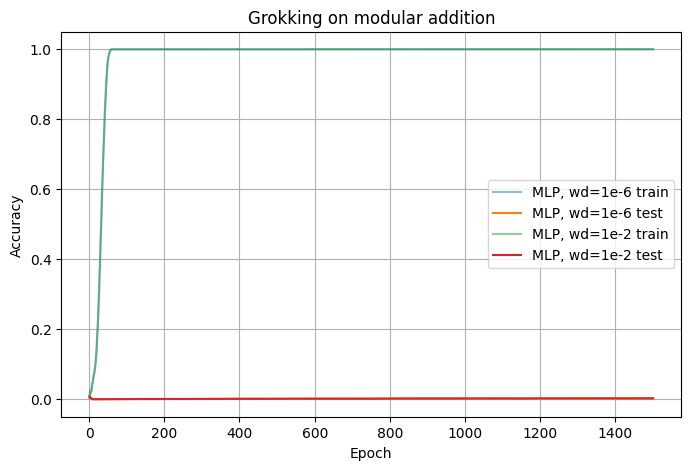

In [17]:

mlp_cfgs = [
    {"label": "MLP, wd=1e-6", "model": ModAddMLP(p=p, hidden=256), "wd": 1e-6},
    {"label": "MLP, wd=1e-2", "model": ModAddMLP(p=p, hidden=256), "wd": 1e-2},
]
mlp_histories = []
for cfg in mlp_cfgs:
    print("Training:", cfg["label"])
    h = train_model(cfg["model"], train_ds, test_ds, epochs=1500, batch_size=1024, lr=3e-3, weight_decay=cfg["wd"], report_every=100)
    h["label"] = cfg["label"]
    mlp_histories.append(h)

plot_histories(mlp_histories)




Compare the curves to the transformer. The qualitative pattern, quick memorization then delayed test improvement, is the signature we care about.

---

## 11. Diagnostics and representation hints

To better understand what happens between the memorization and generalization solutions, add simple probes and norms.

### 11.1 Weight norms over time



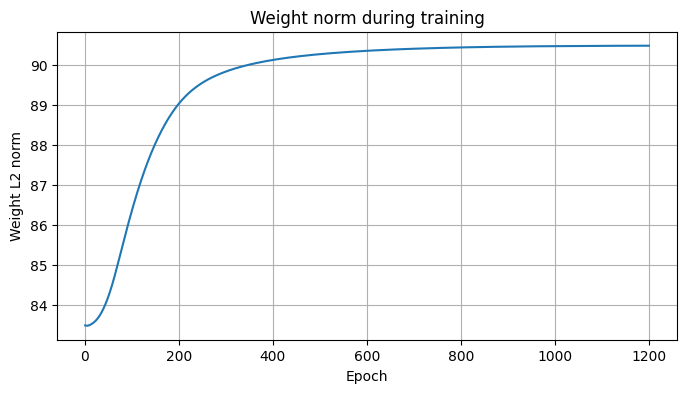

In [18]:

def track_weight_norms(model):
    total = 0.0
    for p in model.parameters():
        total += p.data.norm(2).item() ** 2
    return math.sqrt(total)

def instrumented_training(model, train_ds, test_ds, epochs=1000, batch_size=512, lr=3e-4, weight_decay=1e-2):
    model.to(device)
    train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, drop_last=True)
    test_loader  = DataLoader(test_ds,  batch_size=4096, shuffle=False)
    opt = torch.optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    loss_fn = nn.CrossEntropyLoss()
    hist = {"epoch": [], "train_acc": [], "test_acc": [], "train_loss": [], "test_loss": [], "w_norm": []}
    for ep in range(1, epochs + 1):
        model.train()
        tl = tc = n = 0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            opt.zero_grad()
            logits = model(xb)
            loss = loss_fn(logits, yb)
            loss.backward()
            opt.step()
            tl += loss.item() * xb.size(0); tc += (logits.argmax(1) == yb).sum().item(); n += xb.size(0)
        tr_acc, tr_loss = tc / n, tl / n

        model.eval()
        with torch.no_grad():
            vl = vc = m = 0
            for xb, yb in test_loader:
                xb, yb = xb.to(device), yb.to(device)
                logits = model(xb)
                loss = loss_fn(logits, yb)
                vl += loss.item() * xb.size(0); vc += (logits.argmax(1) == yb).sum().item(); m += xb.size(0)
        te_acc, te_loss = vc / m, vl / m
        hist["epoch"].append(ep)
        hist["train_acc"].append(tr_acc)
        hist["test_acc"].append(te_acc)
        hist["train_loss"].append(tr_loss)
        hist["test_loss"].append(te_loss)
        hist["w_norm"].append(track_weight_norms(model))
    return hist

model = TinyGrokTransformer(p=p, d_model=64, nhead=4, nlayers=2, d_ff=128, dropout=0.0)
hist = instrumented_training(model, train_ds, test_ds, epochs=1200, weight_decay=1e-2)

plt.figure(figsize=(8,4)); plt.plot(hist["epoch"], hist["w_norm"]); plt.xlabel("Epoch"); plt.ylabel("Weight L2 norm"); plt.title("Weight norm during training"); plt.grid(True); plt.show()




You often see weight norms change character around the onset of generalization. This is not a proof of mechanism, it is a useful signal.

### 11.2 Error heatmaps

Visualize where the errors concentrate before and after grokking. Early, the model memorizes training pairs and fails on off-manifold pairs. Late, the pattern becomes globally consistent.



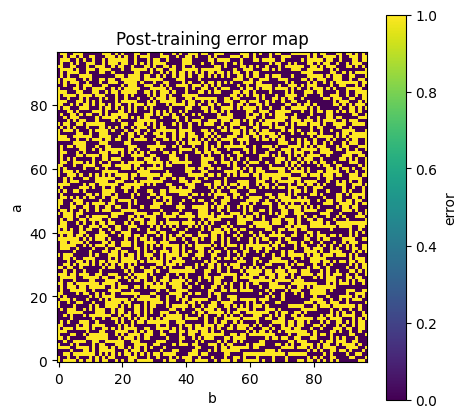

In [19]:

def error_heatmap(model, p=97, title=""):
    model.eval()
    with torch.no_grad():
        A, B = torch.meshgrid(torch.arange(p), torch.arange(p), indexing="ij")
        X = torch.stack([A.flatten(), B.flatten()], dim=1).to(device)
        y = ((A + B) % p).flatten().to(device)
        logits = model(X)
        pred = logits.argmax(dim=-1)
        err = (pred != y).float().cpu().numpy().reshape(p, p)
    plt.figure(figsize=(5,5))
    plt.imshow(err, origin="lower", interpolation="nearest")
    plt.xlabel("b"); plt.ylabel("a"); plt.title(title or "Error heatmap")
    plt.colorbar(label="error")
    plt.show()

error_heatmap(model, p=p, title="Post-training error map")



---

## 12. Design choices that influence grokking

Table of practical levers:

| Lever             | Typical effect                                                                |
| ----------------- | ----------------------------------------------------------------------------- |
| Weight decay      | Larger values accelerate onset of test improvement                            |
| Data fraction     | Smaller train split increases the gap between memorization and generalization |
| Model size        | Larger models memorize faster, often lengthening the plateau                  |
| Batch size        | Smaller batches sometimes help escape local memorization attractors           |
| LR schedule       | Cosine decay or step decay can stabilize late training                        |
| Data augmentation | On algorithmic tasks, structured augmentation reduces stasis                  |

---

## 13. A compact replication recipe

If you only need a quick demo:

1. Use $p = 97$ and train split 50 percent.
2. Transformer with d\_model 64, 2 layers, 4 heads, head on the first token.
3. AdamW with lr 3e-4, weight decay 1e-2, batch size 512.
4. Train for 1200 to 2000 epochs.
5. Plot train and test accuracies. You should see the grokking phase.

---

## 14. Interpreting what you observe

* **Memorization phase:** The model constructs a lookup-like representation. Train accuracy saturates, test accuracy is flat.
* **Stasis:** Parameters drift under weight decay and optimization noise. Competing solutions have similar training loss, but different complexity.
* **Grokking:** The solution with better inductive bias, in this case the group structure of addition modulo $p$, begins to dominate. Test accuracy rises.

This story is consistent with the idea that multiple functions fit the data, the optimization dynamics and regularization gradually favor the lower complexity solution, then a tipping point is reached.

---

## 15. Frequently asked questions

**Does grokking require transformers?** No. It appears with MLPs and CNNs on algorithmic tasks. Transformers make it convenient to replicate.

**Is grokking a small data artifact?** It is easiest to see on small, highly structured problems. The broader lesson, that generalization may arrive late, matters at scale too.

**Should I always train very long?** No. Use validation monitoring and cost awareness. If curves show a classic plateau and you suspect structure, try modestly longer runs with stronger regularization before stopping.

---

## 16. Extensions for classroom or lab

* Try different groups: modular multiplication on $\mathbb{Z}_p^\times$, or 2D vector addition modulo $p$.
* Curriculum: start with a small $p$, then grow $p$ over time. Check if grokking accelerates.
* Probing: train linear probes on hidden states to see when linearly decodable group features emerge.

---

## 17. Minimal MLP version, pure NumPy for teaching

If you do not want PyTorch, here is a toy trainer that shows the general shape, although it runs slower and is less flexible. It is useful for lecture slides.


In [20]:

import numpy as np

def one_hot(n, idx):
    oh = np.zeros((idx.shape[0], n), dtype=np.float32)
    oh[np.arange(idx.shape[0]), idx] = 1.0
    return oh

class TinyNumPyMLP:
    def __init__(self, p=97, hidden=128, seed=0):
        rng = np.random.default_rng(seed)
        self.p = p
        self.W1 = rng.normal(0, 0.05, size=(2*p, hidden))
        self.b1 = np.zeros((hidden,))
        self.W2 = rng.normal(0, 0.05, size=(hidden, p))
        self.b2 = np.zeros((p,))
    def forward(self, X):
        H = np.maximum(0, X @ self.W1 + self.b1)
        Z = H @ self.W2 + self.b2
        return Z, H
    def step(self, X, y, lr=1e-2, wd=0.0):
        Z, H = self.forward(X)
        # softmax cross-entropy
        expZ = np.exp(Z - Z.max(axis=1, keepdims=True))
        P = expZ / expZ.sum(axis=1, keepdims=True)
        N = X.shape[0]
        loss = -np.log(P[np.arange(N), y] + 1e-9).mean()
        # grads
        G = P
        G[np.arange(N), y] -= 1
        G /= N
        dW2 = H.T @ G + wd * self.W2
        db2 = G.sum(axis=0)
        GH = G @ self.W2.T
        GH[H <= 0] = 0
        dW1 = X.T @ GH + wd * self.W1
        db1 = GH.sum(axis=0)
        # update
        self.W2 -= lr * dW2; self.b2 -= lr * db2
        self.W1 -= lr * dW1; self.b1 -= lr * db1
        pred = Z.argmax(axis=1)
        acc = (pred == y).mean()
        return float(loss), float(acc)

# build data
p = 59
pairs = np.array([(a,b) for a in range(p) for b in range(p)], dtype=np.int64)
labels = (pairs[:,0] + pairs[:,1]) % p
rng = np.random.default_rng(3)
idx = rng.permutation(len(pairs))
train_idx, test_idx = idx[:len(idx)//2], idx[len(idx)//2:]
a_train, b_train = pairs[train_idx,0], pairs[train_idx,1]
a_test,  b_test  = pairs[test_idx,0],  pairs[test_idx,1]
Xtr = np.concatenate([one_hot(p, a_train), one_hot(p, b_train)], axis=1)
ytr = labels[train_idx]
Xte = np.concatenate([one_hot(p, a_test),  one_hot(p, b_test)],  axis=1)
yte = labels[test_idx]

mlp = TinyNumPyMLP(p=p, hidden=256, seed=1)
hist = {"train_acc": [], "test_acc": []}
for ep in range(2000):
    # small batches for noise
    batch = rng.choice(len(Xtr), size=512, replace=True)
    loss, acc = mlp.step(Xtr[batch], ytr[batch], lr=5e-3, wd=1e-2)
    if ep % 10 == 0:
        # test
        Z,_ = mlp.forward(Xte)
        te_acc = (Z.argmax(1) == yte).mean()
        hist["train_acc"].append(acc); hist["test_acc"].append(te_acc)


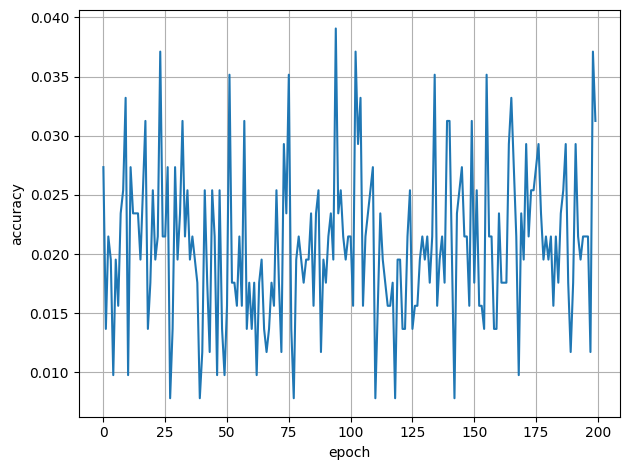

In [24]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(hist['train_acc'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()


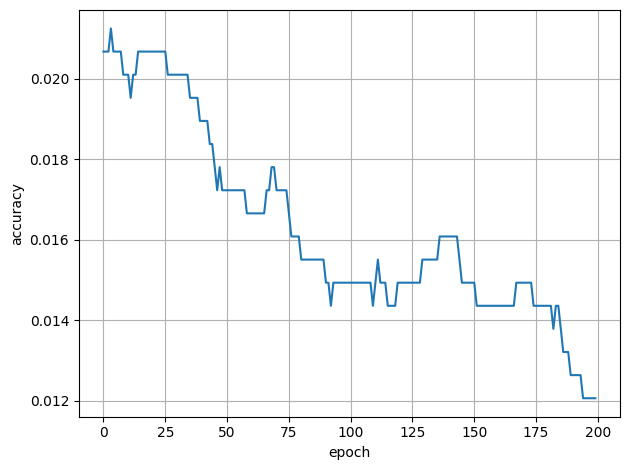

In [25]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(hist['test_acc'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.grid(True)
plt.tight_layout()
plt.show()




Plot `hist["train_acc"]` and `hist["test_acc"]` to see the pattern. This version is for pedagogy, not performance.

---

## 18. Summary and guidance

* Grokking is the delayed transition from memorization to generalization on structured, small data.
* You can reproduce it with modular arithmetic, a small transformer, and a simple training script.
* Weight decay, model capacity, and data fraction are the levers that most strongly affect the onset.
* Do not rely on early stopping alone when structure is present. Consider longer training with stronger regularization and careful monitoring.

---

## 19. Repro tips for reliability

1. Fix random seeds for reproducibility.
2. Use a prime modulus and keep the dataset complete, then split deterministically.
3. Keep the model small so you can afford many epochs.
4. Log both train and test. Look for a flat test plateau followed by a rise.
5. If you do not observe grokking, increase epochs, increase weight decay, or reduce the train fraction.

---

## Summary

Grokking represents a delayed onset of generalization in deep learning, where models first memorize and only later learn the underlying rules. This phenomenon:

* Highlights nontrivial training dynamics
* Challenges standard early stopping heuristics
* Invites deeper investigation into optimization landscapes and implicit bias

In the broader intellectual arc, the repurposing of Heinlein’s term is apt: both in science fiction and machine learning, **to grok** is to cross a threshold from surface-level mimicry to deep, integrated understanding.

